# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer:**

The dataset captures 17 marketing campaigns conducted by a Portuguese bank between May 2008 and November 2010. It consists of 41,188 entries featuring 20 input variables and a binary target (y), which records whether a client subscribed to a term deposit after a telemarketing contact.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [63]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


In [64]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [65]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [66]:
df.shape

(41188, 21)

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [67]:
print("data set info")
df.info()

data set info
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-nu

In [68]:
df.isnull().sum()
#  no null value
print("There is no null or empty value")

print(df['y'].value_counts())

There is no null or empty value
y
no     36548
yes     4640
Name: count, dtype: int64


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Answer:**

The primary business objective is to predict whether a banking client will subscribe to a term deposit based on their profile and historical data.

It is a binary classification problem, The data is imbalance as 11.26% clients subscribe for term deposit and rest did not subscribe.

Bank want to 
1. Improve Campign ROI by focus marketing on high probability clients
2. Identify the most promising clients
3. Reduce marketing cost by avoid market to those clients which are unlikely to subscribe. 

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [69]:
bank_client_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
target_col = 'y'

In [70]:
df_model = df[bank_client_features + [target_col]].copy()

In [71]:
#Encoding the data 
df_model[target_col] = (df_model[target_col] == 'yes').astype(int)

# One-hot encode all categorical features (drop_first to avoid multicollinearity)
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']
df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [72]:
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Train Accuracy -> 0.8873 (88.73%)
Test  Accuracy -> 0.8874 (88.74%)


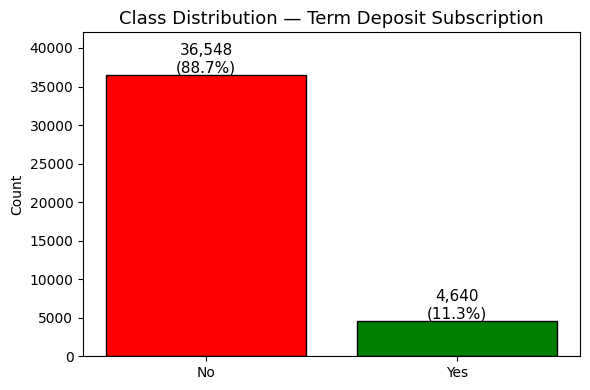

In [74]:
# As per internet we can use DummyClassifier for baseline
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train_scaled, y_train)

baseline_train_acc = dummy_clf.score(X_train_scaled, y_train)
baseline_test_acc  = dummy_clf.score(X_test_scaled, y_test)

print(f"Train Accuracy -> {baseline_train_acc:.4f} ({baseline_train_acc*100:.2f}%)")
print(f"Test  Accuracy -> {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)")

# Visualise target imbalance
fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts()
bars = ax.bar(['No', 'Yes'], counts.values, color=['red', 'green'], edgecolor='black')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{val:,}\n({val/len(y)*100:.1f}%)", ha='center', fontsize=11)
ax.set_title('Class Distribution — Term Deposit Subscription', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig("data/baseline.png")
plt.show()

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [75]:
lr = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
lr.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start

lr_train_acc = lr.score(X_train_scaled, y_train)
lr_test_acc  = lr.score(X_test_scaled, y_test)

print(f"Logistic Regression fitted in {lr_train_time:.4f}s")
print(f"Train Accuracy : {lr_train_acc:.4f} ({lr_train_acc*100:.2f}%)")
print(f"Test  Accuracy : {lr_test_acc:.4f} ({lr_test_acc*100:.2f}%)")

Logistic Regression fitted in 0.0061s
Train Accuracy : 0.8873 (88.73%)
Test  Accuracy : 0.8874 (88.74%)


### Problem 9: Score the Model

What is the accuracy of your model?

Logistic Regression Accuracy score  : 0.8874 (88.74%)


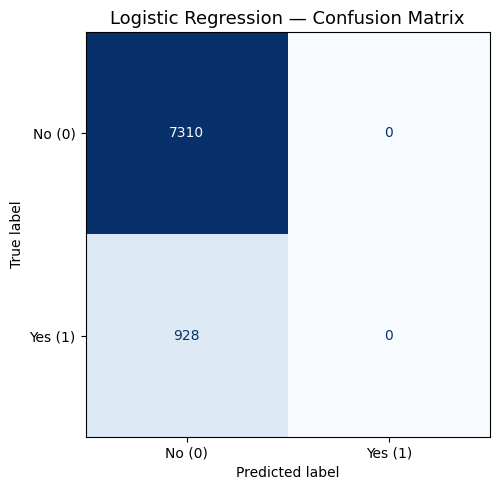

In [76]:
y_pred_lr = lr.predict(X_test_scaled)
lr_accuracy_score = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy score  : {lr_accuracy_score:.4f} ({lr_accuracy_score*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig("data/lr_confusionMatrix.png")
plt.show()

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [77]:
pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    "Knn": Pipeline([
        ('model', KNeighborsClassifier(n_neighbors=15))
    ]),
    "Decision Tree": Pipeline([
        ('model', DecisionTreeClassifier())
    ]),
    "Support Vector Machine": Pipeline([
        ('model', SVC(random_state=42))
    ]),
}

results = []

for name, pipeline in pipelines.items():
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - t0

    train_acc = pipeline.score(X_train_scaled, y_train)
    test_acc  = pipeline.score(X_test_scaled,  y_test)

    results.append({
        'Model'          : name,
        'Train Time (s)' : round(train_time, 4),
        'Train Accuracy' : round(train_acc, 4),
        'Test Accuracy'  : round(test_acc, 4),
    })


results_df = pd.DataFrame(results)
results_df

,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,0.0129,0.8594,0.8577
1,Knn,0.0017,0.8873,0.8874
2,Decision Tree,0.0408,0.7690,0.7646
3,Support Vector Machine,2.8955,0.8873,0.8874


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [78]:
scoring_metric = 'roc_auc'

param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'liblinear'],
            'class_weight': [None, 'balanced']
        }
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 11, 21, 31],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 10, 50],
            'min_samples_leaf': [1, 5, 20],
            'class_weight': [None, 'balanced']
        }
    },
    'Support Vector Machine': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'kernel': ['rbf', 'linear'],
            'class_weight': [None, 'balanced']
        }
    }
}

tuned_results = []
best_estimators = {}

for name, cfg in param_grids.items():
    print(f"\nTuning {name}...")
    t0 = time.time()

    gs = GridSearchCV(
        cfg['model'], cfg['params'],
        scoring=scoring_metric,
        cv=5, n_jobs=-1, refit=True
    )
    gs.fit(X_train, y_train)

    elapsed = time.time() - t0
    best_clf = gs.best_estimator_
    best_estimators[name] = best_clf

    train_acc  = best_clf.score(X_train, y_train)
    test_acc   = best_clf.score(X_test, y_test)
    y_prob     = best_clf.predict_proba(X_test)[:, 1]
    roc_auc    = roc_auc_score(y_test, y_prob)

    tuned_results.append({
        'Model': name,
        'Best Params': gs.best_params_,
        'CV AUC (best)': round(gs.best_score_, 4),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Test ROC-AUC': round(roc_auc, 4),
        'Tuning Time (s)': round(elapsed, 2)
    })

    print(f"Best params: {gs.best_params_}")
    print(f"CV AUC: {gs.best_score_:.4f}")
    print(f"Test Acc: {test_acc:.4f} | Test AUC: {roc_auc:.4f}")
    print(f"Total time: {elapsed:.2f}s")



Tuning Logistic Regression...
Best params: {'C': 0.01, 'class_weight': 'balanced', 'solver': 'lbfgs'}
CV AUC: 0.6498
Test Acc: 0.5747 | Test AUC: 0.6499
Total time: 5.78s

Tuning K-Nearest Neighbors...
Best params: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'uniform'}
CV AUC: 0.6229
Test Acc: 0.8875 | Test AUC: 0.6314
Total time: 46.68s

Tuning Decision Tree...
Best params: {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 50}
CV AUC: 0.6568
Test Acc: 0.6763 | Test AUC: 0.6606
Total time: 2.30s

Tuning Support Vector Machine...
Best params: {'C': 10.0, 'class_weight': 'balanced', 'kernel': 'rbf'}
CV AUC: 0.6546
Test Acc: 0.6252 | Test AUC: 0.6547
Total time: 763.72s


In [79]:
tuned_df = pd.DataFrame(tuned_results)[[
    'Model', 'CV AUC (best)', 'Train Accuracy', 'Test Accuracy', 'Test ROC-AUC', 'Tuning Time (s)'
]]
tuned_df

,Model,CV AUC (best),Train Accuracy,Test Accuracy,Test ROC-AUC,Tuning Time (s)
0,Logistic Regression,0.6498,0.5824,0.5747,0.6499,5.78
1,K-Nearest Neighbors,0.6229,0.8880,0.8875,0.6314,46.68
2,Decision Tree,0.6568,0.6802,0.6763,0.6606,2.30
3,Support Vector Machine,0.6546,0.6293,0.6252,0.6547,763.72


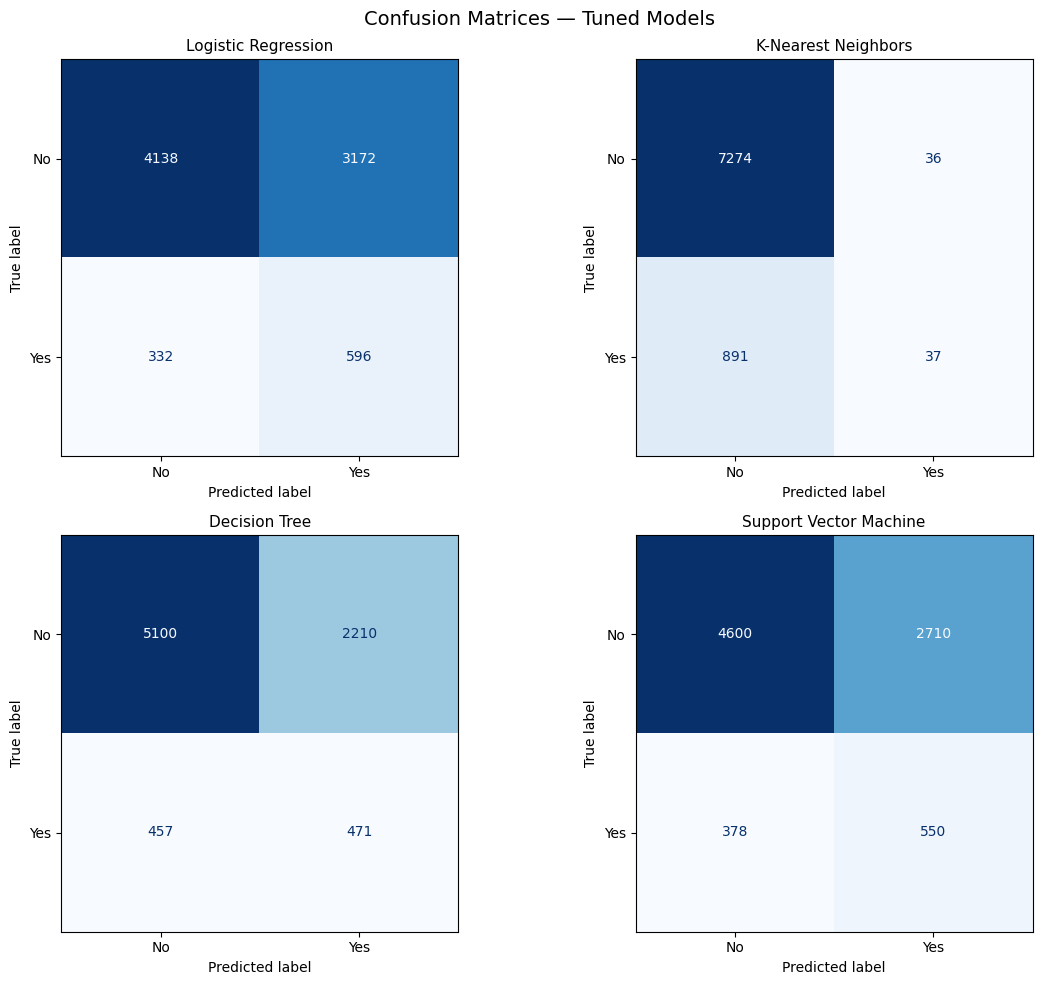

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, clf) in enumerate(best_estimators.items()):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=14)
plt.tight_layout()
plt.savefig("data/confusionMatrix.png")
plt.show()


##### Questions